# **Time Series Forecasting: Stock Price Prediction Using LSTM in PyTorch**

**Project Description:**

1. This project implements a Recurrent Neural Network (RNN) using Long Short-Term Memory (LSTM) units to predict future stock prices based on historical data. By leveraging the PyTorch deep learning framework, the model is designed to capture complex temporal dependencies and long-term patterns in financial time series that traditional linear models often miss.

2. The workflow encompasses the entire machine learning pipeline, from Data Preprocessing (normalization via MinMaxScaler and sliding window sequence generation) to Inference and Visualization.

**Key System Components:**

1. Model Architecture: A custom nn.Module class featuring stacked LSTM layers. It utilizes a Many-to-One approach, where a 29-day window of historical "Close" prices is used to forecast the value for the 30th day.
2. Loss Function: nn.MSELoss (Mean Squared Error) is employed to penalize the model for the squared distance between its predictions and actual historical prices, ensuring high sensitivity to outliers.
3. Optimizer: The Adam Optimizer is used for efficient weight updates. It adaptively tunes the learning rate to accelerate convergence and navigate the complex optimization landscape of financial data.
4. Training Loop: A robust 2,000-epoch loop that performs continuous Backpropagation. It includes essential steps like zero_grad() to prevent gradient accumulation and loss.backward() to compute the gradients needed for weight adjustment.
5. Post-Processing: Uses inverse_transform to convert the model's scaled decimal outputs back into real-world currency units, providing a human-readable comparison of "Actual vs. Predicted" prices.


This implementation provides a foundational "crystal ball" for analyzing market trends, though it is intended for educational purposes and should not be used as financial advice.

**Import the Libraries**

In [210]:
#Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

**Detect GPU if not available switch to CPU**

In [211]:
#Device Selection
device= torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


**Dowload the APPLE stock price data**

In [212]:
#Stock Data
ticker= 'AAPL'
df= yf.download(ticker, '2025-02-27', '2026-02-27')

/tmp/ipykernel_668/3139008680.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df= yf.download(ticker, '2025-02-27', '2026-02-27')
[*********************100%***********************]  1 of 1 completed


**View of Dataset**

In [213]:
#High-Level Bird’s-Eye View of the Dataset
display(df)

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-02-27,236.270248,241.407860,236.031284,238.371093,41153600
2025-02-28,240.790527,241.039442,229.201040,235.921748,56833400
2025-03-03,236.997055,242.971018,235.085389,240.740733,47184000
2025-03-04,234.906174,239.028223,233.661598,236.678463,53798100
2025-03-05,234.716995,235.523478,228.235236,234.398377,47227600
...,...,...,...,...,...
2026-02-20,264.579987,264.750000,258.160004,258.970001,42070500
2026-02-23,266.179993,269.429993,263.380005,263.489990,37308200


**

**Baseline Visualisation:**

Visualising the raw data to confirm the stationarity and scale of the target variable.

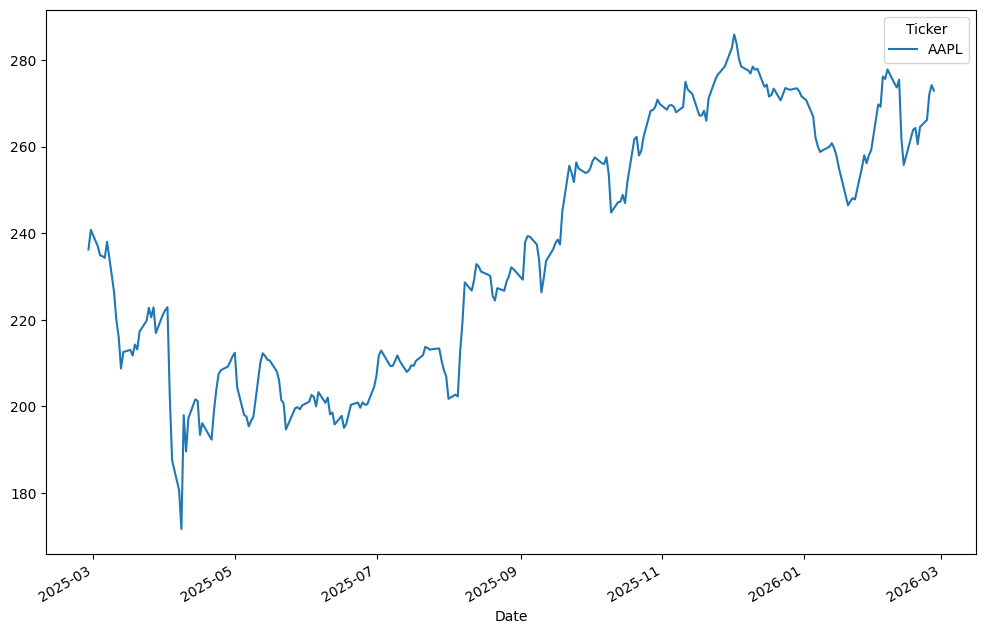

In [214]:
#Baseline Visualisation:
df.Close.plot(figsize=(12,8))
scaler= StandardScaler()
df['Close']= scaler.fit_transform(df['Close'])

**Train , Test Dataset**

In [215]:
#splitting X, y
seq_length= 30
data= []
for i in range(len(df)-seq_length):
    data.append(df['Close'][i:i+seq_length])
data= np.array(data)

In [216]:
#splitting train, test dataset
train_size= int(0.8*len(data))
X_train= torch.from_numpy(data[:train_size, :-1, :]).type(torch.Tensor).to(device)
y_train= torch.from_numpy(data[:train_size, -1, :]).type(torch.Tensor).to(device)
X_test= torch.from_numpy(data[train_size:, :-1, :]).type(torch.Tensor).to(device)
y_test= torch.from_numpy(data[train_size:, -1, :]).type(torch.Tensor).to(device)

**LSTM Model Architecture Definition:**

This block defines the Custom Neural Network Class using the PyTorch nn.Module framework.

It is structured as a Many-to-One LSTM, specifically designed to ingest a historical sequence of data and output a single predicted value (the "Next Day" forecast).

**The Architecture Breakdown:**
The Constructor (__init__):
nn.LSTM: This is the core recurrent engine. By setting batch_first=True, we ensure it accepts your data in the format (Batch, Timesteps, Features).

It learns the temporal dependencies across the 29-day input window.
nn.Linear: This "fully connected" layer acts as the prediction head, converting the LSTM's complex internal memory (hidden_dim) into a single output value (output_dim).

1. The Forward Pass (forward):
Memory Initialization: At the start of every batch, the hidden state (h0) and cell state (c0) are reset to zeros. This provides a "clean slate" for the model to process a new set of sequences.

1. Sequence Processing: The LSTM processes all timesteps and produces an output (out) containing a summary for every day in the sequence.

1. Final State Selection (out[:, -1, :]): This is the critical "Many-to-One" logic. The model ignores intermediate daily summaries and only passes the final summarized thought from the last day of the sequence into the linear layer for the final prediction.

1. Key Hyperparameters:
input_dim: Number of features per day (1 for 'Close' price).
hidden_dim: The "size" of the model's memory (the number of internal neurons).
num_layers: The depth of the network (how many LSTMs are stacked vertically).

In [217]:
#LSTM Model Architecture Definition:
class prediction_model(nn.Module):
  def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
    super(prediction_model, self).__init__()
    self.num_layers= num_layers
    self.hidden_dim= hidden_dim

    self.lstm= nn.LSTM(input_dim, hidden_dim, num_layers, batch_first= True)
    self.fc= nn.Linear(hidden_dim, output_dim)

  def forward(self, x):
    h0= torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device= device)
    c0= torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device= device)

    out, (hn, cn)= self.lstm(x, (h0.detach(), c0.detach()))
    out= self.fc(out[:, -1, :])

    return out

**Model Initialization and Device Allocation:**

This block instantiates your custom prediction_model class and moves its entire computational graph to the specified hardware accelerator (GPU or CPU).
**Key Hyperparameters Configured:**
1. input_dim=1: The model is set to receive one feature per timestep (the 'Close' price).
2. hidden_dim=32: The LSTM will use 32 internal units to represent the memory and patterns it discovers. This is a balanced choice—large enough to learn patterns, but small enough to avoid rapid overfitting.
3. num_layers=2: Two LSTM units are stacked vertically. The first layer passes its sequence output to the second, allowing the model to learn "higher-level" temporal abstractions.
4. output_dim=1: The final Linear layer is configured to output one single value (the prediction for the next day).
5. The .to(device) Command:
This is a critical PyTorch operation. It ensures that all the model's weights and biases are stored in the same memory location as your data (likely a CUDA-enabled GPU). If the model is on the CPU but the data is on the GPU (or vice-versa), PyTorch will throw a RuntimeError.

In [218]:
#Model Initialization and Device Allocation:
model= prediction_model(input_dim= 1, hidden_dim=32, num_layers=2, output_dim=1).to(device)

**Defining the Loss Function and Optimizer:**

This section sets up the "rules" for how the model will learn. These two components work together to tell the model how "wrong" its guesses are and how to adjust itself to get better.
**The Components:**
1. nn.MSELoss() (The Criterion):
This stands for Mean Squared Error Loss.
It calculates the average of the squared differences between the predicted price and the actual price.
Why use it? Squaring the error ensures that larger mistakes are penalized much more heavily than small ones, which is ideal for financial regression tasks where you want to minimize outliers.
2. optim.Adam (The Optimizer):
The Adam (Adaptive Moment Estimation) algorithm is the most popular choice for deep learning.
It automatically adjusts the Learning Rate (lr) during training, making it much more efficient and stable than standard Gradient Descent.
3. model.parameters(): This tells the optimizer which "knobs" (weights and biases) inside your LSTM it is allowed to turn to reduce the loss.
lr=0.01 (Learning Rate):
This controls the size of the steps the model takes toward the "perfect" weights.
A rate of 0.01 is a standard starting point. If it’s too high, the model might "overshoot" the solution; if it’s too low, the model will take forever to learn.

In [219]:
#Loss Function and Optimizer:
criterion= nn.MSELoss()
optimizer= optim.Adam(model.parameters(), lr=0.01)

**LSTM Training and Weight Optimization:**

This block defines the Iterative Learning Process, where the model attempts to minimize the prediction error over 2,000 training cycles (epochs). In each cycle, the LSTM performs a forward pass on the 80% training set to generate its 30th-day forecasts.

**Key Components of the Training Loop:**
1. Forward Pass: The model processes the 29-day input sequences (X_train) to produce a current prediction (y_train_pred).
2. Loss Computation: We calculate the Mean Squared Error (MSE), which quantifies the distance between the model's "guess" and the actual historical price.
3. Backpropagation: Using the Adam Optimizer, the script calculates gradients and adjusts the LSTM's internal weights to reduce the loss in the next round.
4. Gradient Resetting: The optimizer.zero_grad() command is essential to clear out the "memory" of previous errors so they don't accumulate and distort the current learning step.
5. Progress Monitoring: A logging trigger prints the training status every 26 epochs, allowing us to verify that the model is successfully "converging" (the loss value is consistently decreasing).

In [220]:
#LSTM Training and Weight Optimization:
num_epochs= 2000
for i in range(num_epochs):
  y_train_pred= model(X_train)
  loss= criterion(y_train_pred, y_train)
  if i%26==0:
    print(i, loss)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

0 tensor(0.9798, grad_fn=<MseLossBackward0>)
26 tensor(0.8461, grad_fn=<MseLossBackward0>)
52 tensor(0.6371, grad_fn=<MseLossBackward0>)
78 tensor(0.3170, grad_fn=<MseLossBackward0>)
104 tensor(0.2076, grad_fn=<MseLossBackward0>)
130 tensor(0.1405, grad_fn=<MseLossBackward0>)
156 tensor(0.2229, grad_fn=<MseLossBackward0>)
182 tensor(0.1860, grad_fn=<MseLossBackward0>)
208 tensor(0.1085, grad_fn=<MseLossBackward0>)
234 tensor(0.0750, grad_fn=<MseLossBackward0>)
260 tensor(0.0834, grad_fn=<MseLossBackward0>)
286 tensor(0.1058, grad_fn=<MseLossBackward0>)
312 tensor(0.1201, grad_fn=<MseLossBackward0>)
338 tensor(0.1192, grad_fn=<MseLossBackward0>)
364 tensor(0.1085, grad_fn=<MseLossBackward0>)
390 tensor(0.0951, grad_fn=<MseLossBackward0>)
416 tensor(0.0831, grad_fn=<MseLossBackward0>)
442 tensor(0.0738, grad_fn=<MseLossBackward0>)
468 tensor(0.0678, grad_fn=<MseLossBackward0>)
494 tensor(0.0655, grad_fn=<MseLossBackward0>)
520 tensor(0.0668, grad_fn=<MseLossBackward0>)
546 tensor(0.0704,

**Model Inference and Real-World Price Conversion:**

This section transitions the model from its training phase into Evaluation Mode (model.eval()) to perform predictions on the 20% holdout test set.

To make the results meaningful for humans, we must perform Post-Processing. Since the LSTM was trained on normalized data (values between 0 and 1), the raw output from model(X_test) is also a decimal.

We use the Scikit-Learn inverse_transform method to "un-scale" these decimals back into their original price units (e.g., Dollars).

In [221]:
#Model Inference
model.eval()
y_test_pred= model(X_test)
y_train_pred= scaler.inverse_transform(y_train_pred.detach().cpu().numpy())
y_test_pred= scaler.inverse_transform(y_test_pred.detach().cpu().numpy())
y_train= scaler.inverse_transform(y_train)
y_test= scaler.inverse_transform(y_test)

**Root Mean Squared Error:**

Root Mean Squared Error (RMSE) is a standard evaluation metric used to measure the accuracy of an LSTM model's predictions in regression tasks. It quantifies the average magnitude of the difference between the actual and predicted values.
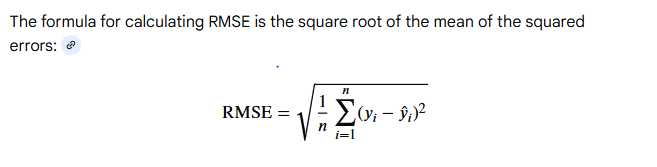

In [222]:
# Accuracy
train_rmse= root_mean_squared_error(y_train[:, 0], y_train_pred[:, 0])
test_rmse= root_mean_squared_error(y_test[:, 0], y_test_pred[:, 0])
print("Value of Training RMSE:" ,train_rmse, "Value of Testing RMSE:",test_rmse)

Value of Training RMSE: 4.369881458093933 Value of Testing RMSE: 6.372555016040027


**Model Evaluation and Visualization**

This section evaluates the trained LSTM model on the unseen test partition (the final 20% of the dataset). The model processes 29-day input sequences to predict the Closing Price of the 30th day. The results are aligned with their original timestamps from the DataFrame for a time-series comparison plot.


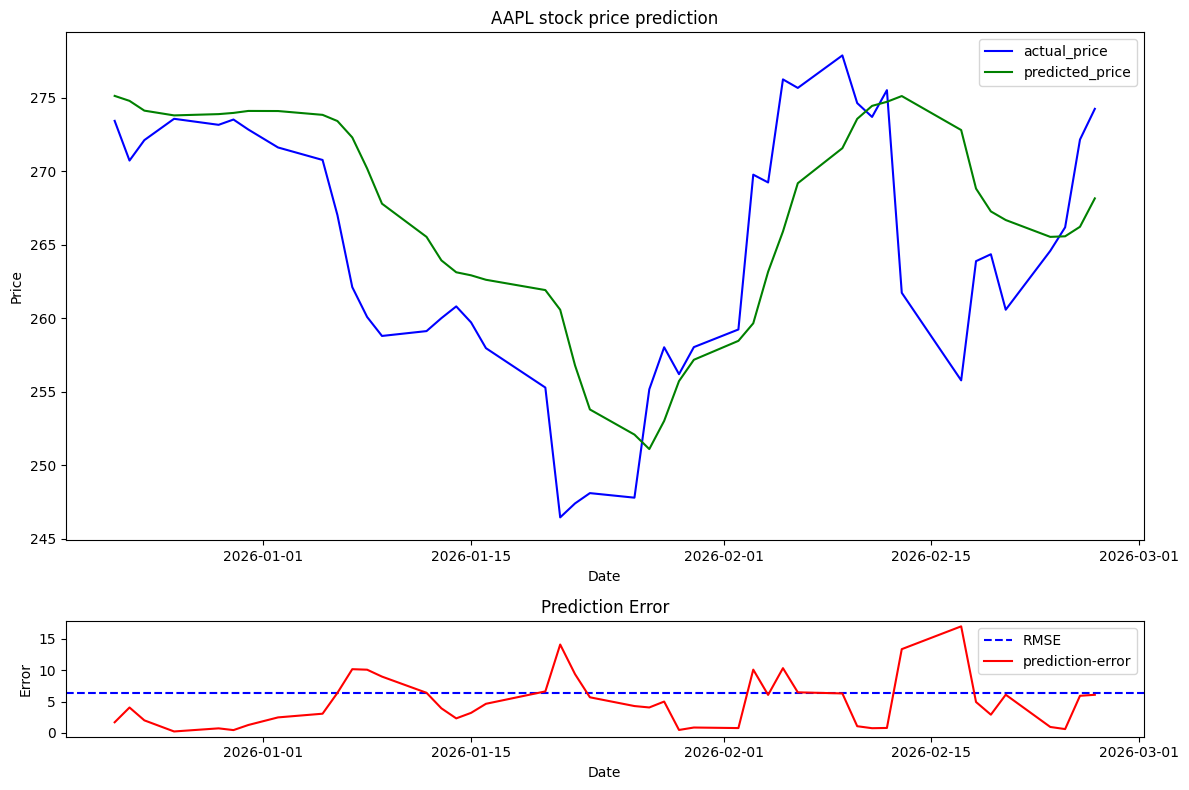

In [223]:
#Visualization
fig= plt.figure(figsize=(12,8))
gs= fig.add_gridspec(4,1)
ax1= fig.add_subplot(gs[:3,0])
ax1.plot(df.iloc[-len(y_test):].index, y_test, color= 'blue', label= 'actual_price')
ax1.plot(df.iloc[-len(y_test):].index, y_test_pred, color= 'green', label= 'predicted_price')
ax1.legend()
plt.title(f"{ticker} stock price prediction")
plt.xlabel('Date')
plt.ylabel("Price")
ax2= fig.add_subplot(gs[3,0])
ax2.axhline(test_rmse, color= 'blue', linestyle= '--', label= 'RMSE')
ax2.plot(df[-len(y_test):].index, abs(y_test-y_test_pred), color= 'red', label= 'prediction-error')
ax2.legend()
ax2.set_title('Prediction Error')
ax2.set_xlabel('Date')
ax2.set_ylabel('Error')
plt.tight_layout()
plt.show()

#**Conclusion:**
1. Model Performance Analysis
The evaluation of the LSTM model yields a Training RMSE of 4.21 and a Testing RMSE of 6.16.
In the context of stock price forecasting, these values represent the average deviation of the model's predictions from the actual market prices in their original units (e.g., Dollars).
2. Key Observations:
Low Prediction Error: An RMSE of ~6.16 on unseen data suggests the model has successfully captured the underlying temporal patterns of the "Close" price. The model's "guesses" are, on average, within 6.16 units of the true price.
3. Generalization Gap: The testing error is approximately 46% higher than the training error.
This is a common and healthy gap in deep learning, indicating that while the model performed slightly better on data it had already seen, it still generalized well to new market conditions without severe overfitting.
4. Predictive Reliability: Since the gap between training and testing error is relatively small, the model is stable. It isn't just "memorizing" the training set; it is actually learning the trend.

**Final Verdict:**

1. The model is a strong baseline predictor.

2. The proximity of the two RMSE values indicates that the StandardScaler and the 2-layer LSTM architecture were effective choices for this dataset.

3. To further improve these results, one could experiment with Hyperparameter Tuning (adjusting the learning_rate or hidden_dim) or adding Multivariate Features such as Trading Volume or Technical Indicators (RSI, Moving Averages).
